In [1]:
%load_ext autoreload
%autoreload 2

import sys
from functools import partial
from matplotlib import pyplot as plt
import numpy as np
import jax
from jax import numpy as jnp
sys.path.append('../src')
jax.config.update("jax_enable_x64", True)

import matplotlib as mpl
colors = plt.cm.plasma_r(np.linspace(0, 1, 6))[1:-1]
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)

from smbhb_jax import smbhb_jax, _period_observed

/home/phuijse/Work/PLATO_spikey/.venv/lib/python3.13/site-packages/astropy/config/paths.py:55: AstropyUserWarning: XDG_CONFIG_HOME is set to '/home/phuijse/.config', but the default location, /home/phuijse/.astropy/config, already exists, and takes precedence. This environment variable will be ignored.
  return set_temp_config._get_dir_path(rootname)


# Reproducing Spikey

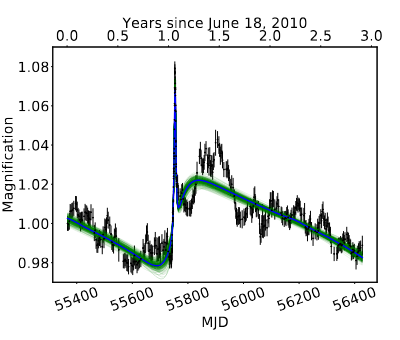

Text(0, 0.5, 'Magnification')

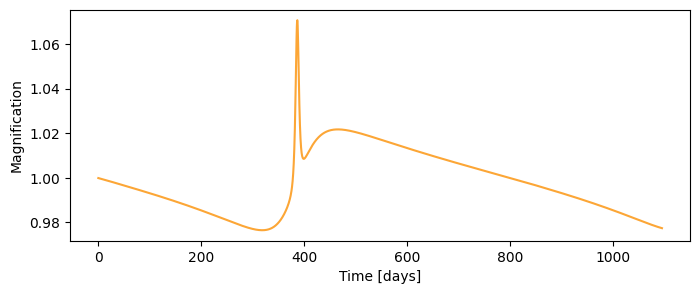

In [2]:
spikey_params = {
    'z': 0.918, 't0': 1.050, 'P': 1.144, 'i': float(np.rad2deg(jnp.arccos(0.140))), 'e': 0.524, 'w': float(jnp.rad2deg(1.477)),
    'L': 0.89, 'alpha': 2.09, 'vz': 0.0, 'logM1': 7.4, 'logM2': 6.7,
}

time = jnp.linspace(0, 3*365.25, 2000)
smbhb_partial = jax.vmap(partial(smbhb_jax, **spikey_params))

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(time, smbhb_partial(time))
ax.set_xlabel('Time [days]')
ax.set_ylabel('Magnification')

# Reproducing Fig. 2 in Hu et al. 2020

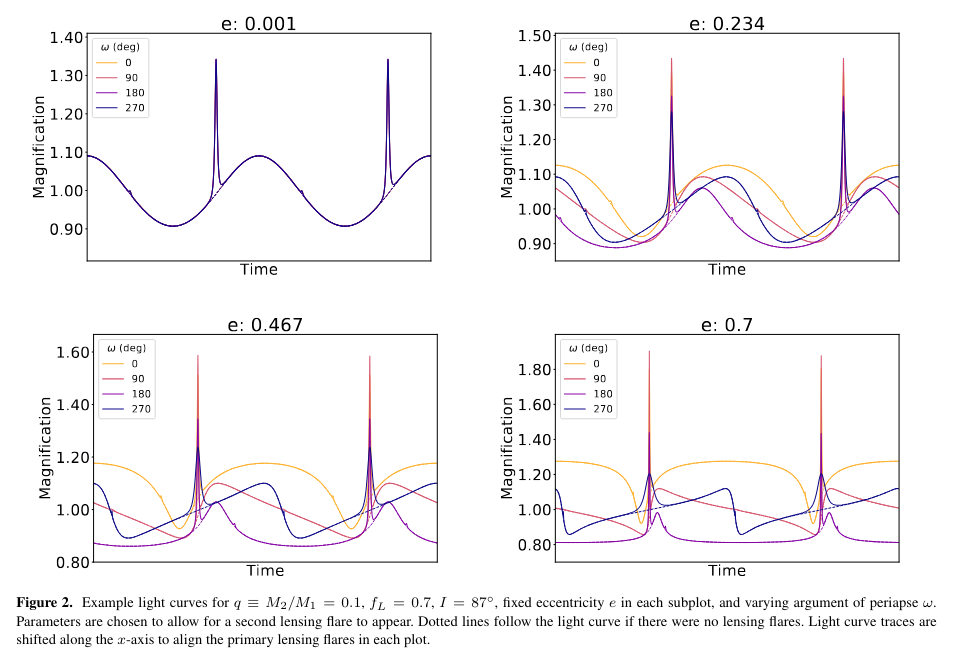

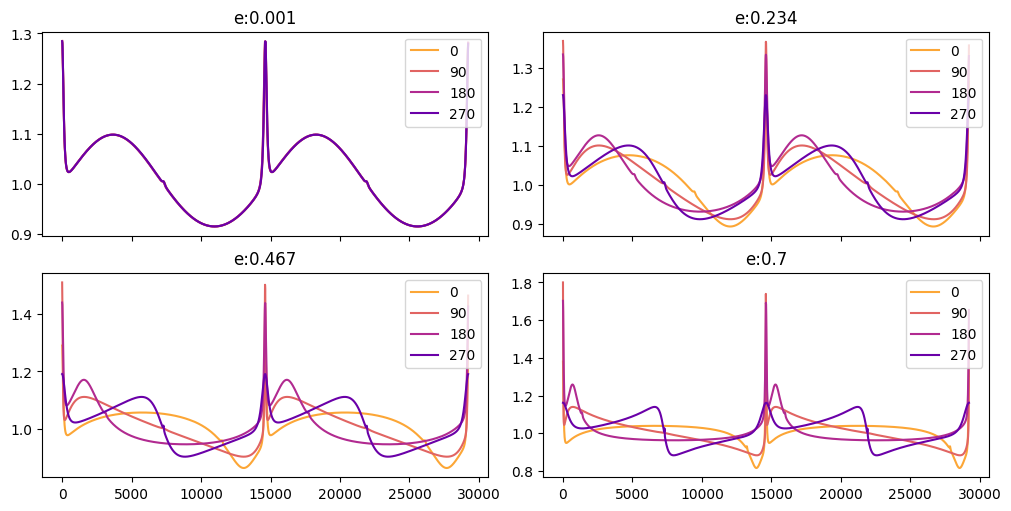

In [3]:
example_params = {
    'P': 20.0, 'L': 0.7, 'i': 87.0, 'logM1': jnp.log10(5) + 8, 'logM2': jnp.log10(5) + 7, # From paper
    'e': 0.001, 'w': 0.0, # to be changed per plot
    't0': 10.0, 'alpha': -2, 'vz': 0, 'z': 1.0, # Not specified in the paper
}

obs_P = _period_observed(example_params['P'], example_params['z'])
time = jnp.linspace(0, obs_P*2*365.25, 2000) # Twice observed period
fig, axs = plt.subplots(2, 2, figsize=(10, 5), sharex=True, sharey=False, constrained_layout=True)

for ax, e in zip(axs.ravel(), [0.001, 0.234, 0.467, 0.7]):
    params = example_params.copy()
    params['e'] = e
    for w in [0, 90, 180, 270]:
        params['w'] = w
        flux = jax.vmap(partial(smbhb_jax, **params))(time)
        idx_max = np.argmax(flux)
        flux = np.roll(flux, -idx_max) # Align with maxima
        ax.plot(time, flux, label=w)
    ax.set_title(f'e:{e}')
    ax.legend()